# Colab HuggingFace Retrieval Experiment

이 노트북은 Colab에서 공유 데이터 기반 RAG 검색 실험을 실행하기 위한 실행 파일입니다.

목표:
- VM 디스크/CPU 부담을 줄이기 위해 Colab에서 index 생성과 prediction 생성을 실행합니다.
- OpenAI embedding 대신 HuggingFace embedding preset(`koe5`, `bge-m3`, `kure`)을 사용합니다.
- `BM25`, `Dense`, `Hybrid`, `Rerank` 조합을 여러 개 실행하고 결과를 표/그래프로 비교합니다.
- `VECTOR_STORE` 설정으로 `faiss` 또는 `chroma`를 선택할 수 있습니다.
- 결과 파일은 Google Drive에 저장해서 나중에 VM 결과와 합칩니다.

주의:
- 이 노트북에는 API key를 저장하지 않습니다.
- `--generate-answer`, `--multi-query`를 사용하지 않으면 OpenAI API key가 필요 없습니다.
- Colab은 VM의 `/home/codeit/shared_file/...` 경로를 볼 수 없습니다. 데이터는 Google Drive에 올려두고 Drive 경로로 읽어야 합니다.
- Chroma DB는 Drive에 직접 만들지 말고 `/content/chroma/...` 같은 Colab 로컬 경로에 만드세요.

In [81]:
# 1. 실험 설정
# 아래 값만 본인 Drive 구조에 맞게 수정하면 됩니다.

from pathlib import Path

DRIVE_ROOT = Path('/content/drive/MyDrive/data/rag_files')
PROJECT_DIR = Path('/content/chatbot')

# 프로젝트 코드를 Colab에 준비하는 방법 중 하나를 선택합니다.
# 1) GitHub repo를 쓸 경우 REPO_URL을 채웁니다.
# 2) Drive에 chatbot 폴더를 통째로 올려둔 경우 DRIVE_PROJECT_DIR을 사용합니다.
# 3) Drive에 chatbot.zip을 올려둔 경우 PROJECT_ZIP을 사용합니다.
REPO_URL = 'https://github.com/beomsookim1020/chatbot.git'  # 예: 'https://github.com/your-team/chatbot.git'
REPO_BRANCH = 'beomsoo'
DRIVE_PROJECT_DIR = DRIVE_ROOT / 'chatbot'
PROJECT_ZIP = DRIVE_ROOT / 'chatbot.zip'

# Drive에 올려둔 데이터 위치입니다.
DATA_PATHS = {
    'soyeon': DRIVE_ROOT / 'soyeon/chunks_v2_690.jsonl',
    'yongjun': DRIVE_ROOT / 'yongjun/rag_database.jsonl',
}

# eval csv가 repo에 없다면 Drive의 이 경로에서 PROJECT_DIR/data/eval로 복사합니다.
DRIVE_EVAL_DIR = DRIVE_ROOT / 'eval'

# 비교하고 싶은 데이터셋과 retriever 조합입니다.
DATASETS_TO_RUN = ['soyeon', 'yongjun']
EMBEDDING_PRESET = 'koe5'  # 선택지: 'koe5', 'bge-m3', 'kure'
VECTOR_STORE = 'chroma'     # 선택지: 'faiss', 'chroma'
TOP_K = 5
HYBRID_FETCH_K = 10 if VECTOR_STORE == 'chroma' else 50
RERANK_CANDIDATES = 10 if VECTOR_STORE == 'chroma' else 30
CANONICAL_ONLY = True
OVERWRITE_PREDICTIONS = False

EXPERIMENT_CONFIGS = [
    {'name': 'bm25', 'retriever': 'bm25', 'rerank': False},
    {'name': 'bm25_rerank', 'retriever': 'bm25', 'rerank': True},
    {'name': 'dense', 'retriever': 'dense', 'rerank': False},
    {'name': 'dense_rerank', 'retriever': 'dense', 'rerank': True},
    {'name': 'hybrid', 'retriever': 'hybrid', 'rerank': False, 'hybrid_fetch_k': HYBRID_FETCH_K},
    {'name': 'hybrid_rerank', 'retriever': 'hybrid', 'rerank': True, 'hybrid_fetch_k': HYBRID_FETCH_K},
]

# Chroma를 쓸 때 collection 이름 prefix입니다.
CHROMA_COLLECTION_PREFIX = 'rfp'

# 이미 index/vector DB를 만들어둔 경우 False로 바꾸면 재생성을 건너뜁니다.
BUILD_INDEX = True
GENERATE_PREDICTIONS = True
RUN_EVALUATION = True

# Colab 로컬 vector DB를 Drive zip으로 저장/복원합니다.
CACHE_VECTOR_STORE = True
OVERWRITE_INDEX_CACHE = False

LOCAL_INDEX_ROOT = Path('/content/indexes')
LOCAL_CHROMA_ROOT = Path('/content/chroma')
DRIVE_OUTPUT_ROOT = DRIVE_ROOT / 'outputs/colab_hf_experiments'
DRIVE_INDEX_ROOT = DRIVE_OUTPUT_ROOT / 'indexes'

assert VECTOR_STORE in {'faiss', 'chroma'}, "VECTOR_STORE는 'faiss' 또는 'chroma'여야 합니다."
for config in EXPERIMENT_CONFIGS:
    assert config['retriever'] in {'bm25', 'dense', 'hybrid'}, f"지원하지 않는 retriever: {config}"

print('DRIVE_ROOT:', DRIVE_ROOT)
print('PROJECT_DIR:', PROJECT_DIR)
print('DATASETS_TO_RUN:', DATASETS_TO_RUN)
print('EMBEDDING_PRESET:', EMBEDDING_PRESET)
print('VECTOR_STORE:', VECTOR_STORE)
print('EXPERIMENT_CONFIGS:', [config['name'] for config in EXPERIMENT_CONFIGS])
print('HYBRID_FETCH_K:', HYBRID_FETCH_K)
print('RERANK_CANDIDATES:', RERANK_CANDIDATES)

DRIVE_ROOT: /content/drive/MyDrive/data/rag_files
PROJECT_DIR: /content/chatbot
DATASETS_TO_RUN: ['soyeon', 'yongjun']
EMBEDDING_PRESET: koe5
VECTOR_STORE: chroma
EXPERIMENT_CONFIGS: ['bm25', 'bm25_rerank', 'dense', 'dense_rerank', 'hybrid', 'hybrid_rerank']
HYBRID_FETCH_K: 10
RERANK_CANDIDATES: 10


In [82]:
# 2. Google Drive mount
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('google.colab 모듈이 없습니다. 이 셀은 Colab 환경에서 실행하세요.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
# 3. 프로젝트 코드 준비
# 우선순위: /content/chatbot 기존 폴더 -> Drive chatbot 폴더 복사 -> Drive zip 압축해제 -> Git clone

import os
import shutil
import subprocess
import sys
from pathlib import Path


def has_project_files(path: Path) -> bool:
    return (path / 'scripts/generate_eval_predictions.py').exists() and (path / 'src').exists()

if has_project_files(PROJECT_DIR):
    print('프로젝트가 이미 준비되어 있습니다:', PROJECT_DIR)
elif DRIVE_PROJECT_DIR.exists() and has_project_files(DRIVE_PROJECT_DIR):
    print('Drive 프로젝트 폴더를 /content로 복사합니다:', DRIVE_PROJECT_DIR)
    if PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    ignore = shutil.ignore_patterns('.venv', '__pycache__', '.git', 'indexes', 'outputs')
    shutil.copytree(DRIVE_PROJECT_DIR, PROJECT_DIR, ignore=ignore)
elif PROJECT_ZIP.exists():
    print('Drive 프로젝트 zip을 압축 해제합니다:', PROJECT_ZIP)
    if PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    subprocess.run(['unzip', '-q', str(PROJECT_ZIP), '-d', '/content'], check=True)
    if not has_project_files(PROJECT_DIR):
        candidates = [p for p in Path('/content').iterdir() if p.is_dir() and has_project_files(p)]
        if candidates:
            candidates[0].rename(PROJECT_DIR)
elif REPO_URL:
    print('GitHub repo를 clone합니다:', REPO_URL, 'branch=', REPO_BRANCH)
    if PROJECT_DIR.exists():
        shutil.rmtree(PROJECT_DIR)
    clone_cmd = ['git', 'clone']
    if REPO_BRANCH:
        clone_cmd.extend(['--branch', REPO_BRANCH, '--single-branch'])
    clone_cmd.extend([REPO_URL, str(PROJECT_DIR)])
    subprocess.run(clone_cmd, check=True)
else:
    raise FileNotFoundError(
        '프로젝트 코드를 찾지 못했습니다. REPO_URL을 채우거나, Drive에 chatbot 폴더 또는 chatbot.zip을 준비하세요.'
    )

assert has_project_files(PROJECT_DIR), f'프로젝트 파일이 올바르지 않습니다: {PROJECT_DIR}'

# Chroma + metadata filter 조합에서 SQLite 변수 제한을 피하기 위한 Colab runtime patch입니다.
dense_path = PROJECT_DIR / 'src/retriever/dense.py'
dense_text = dense_path.read_text(encoding='utf-8')
dense_text = dense_text.replace(
    '        results: List[dict[str, Any]] = []\n'
    '        search_k = max(fetch_k or top_k * 50, top_k, 100)\n'
    '        max_k = self._count_vectors() or search_k\n',
    '        results: List[dict[str, Any]] = []\n'
    '        search_k = max(fetch_k or top_k * 10, top_k)\n'
    '        max_k = self._count_vectors() or search_k\n'
    '        if self.vector_store.__class__.__name__ == "ChromaVectorStore":\n'
    '            max_k = min(max_k, max(search_k, 25))\n',
)
dense_path.write_text(dense_text, encoding='utf-8')

hybrid_path = PROJECT_DIR / 'src/retriever/hybrid.py'
hybrid_text = hybrid_path.read_text(encoding='utf-8')
hybrid_text = hybrid_text.replace(
    '            fetch_k=max(candidate_k * 10, 100),\n',
    '            fetch_k=candidate_k,\n',
)
hybrid_text = hybrid_text.replace(
    '            key = str(result.get("chunk_id") or f"{result.get(\'doc_id\')}:{rank}:{source}")\n',
    '            key = _result_key(result, fallback=f"{rank}:{source}")\n',
)
if 'def _result_key(result: dict[str, Any], fallback: str) -> str:' not in hybrid_text:
    hybrid_text += (
        '\n\n'
        'def _result_key(result: dict[str, Any], fallback: str) -> str:\n'
        '    metadata = result.get("metadata") or {}\n'
        '    doc_id = result.get("doc_id") or metadata.get("doc_id") or metadata.get("source_file")\n'
        '    chunk_id = result.get("chunk_id") or metadata.get("chunk_id")\n'
        '    if doc_id is not None and chunk_id is not None:\n'
        '        return f"{doc_id}:{chunk_id}"\n'
        '    if chunk_id is not None:\n'
        '        return f"chunk:{chunk_id}"\n'
        '    return f"{doc_id or \'unknown\'}:{fallback}"\n'
    )
hybrid_path.write_text(hybrid_text, encoding='utf-8')

multiquery_path = PROJECT_DIR / 'src/retriever/multiquery.py'
multiquery_text = multiquery_path.read_text(encoding='utf-8')
multiquery_text = multiquery_text.replace(
    '                key = str(result.get("chunk_id") or f"{result.get(\'doc_id\')}:{rank}:{query_idx}")\n',
    '                key = _result_key(result, fallback=f"{rank}:{query_idx}")\n',
)
if 'def _result_key(result: dict[str, Any], fallback: str) -> str:' not in multiquery_text:
    multiquery_text += (
        '\n\n'
        'def _result_key(result: dict[str, Any], fallback: str) -> str:\n'
        '    metadata = result.get("metadata") or {}\n'
        '    doc_id = result.get("doc_id") or metadata.get("doc_id") or metadata.get("source_file")\n'
        '    chunk_id = result.get("chunk_id") or metadata.get("chunk_id")\n'
        '    if doc_id is not None and chunk_id is not None:\n'
        '        return f"{doc_id}:{chunk_id}"\n'
        '    if chunk_id is not None:\n'
        '        return f"chunk:{chunk_id}"\n'
        '    return f"{doc_id or \'unknown\'}:{fallback}"\n'
    )
multiquery_path.write_text(multiquery_text, encoding='utf-8')

chroma_path = PROJECT_DIR / 'src/vectorstore/chroma_store.py'
chroma_text = chroma_path.read_text(encoding='utf-8')
chroma_text = chroma_text.replace(
    '        ids = [str(chunk["chunk_id"]) for chunk in self.chunks]\n',
    '        ids = [\n'
    '            f"{chunk.get(\'doc_id\') or \'doc\'}:{chunk.get(\'chunk_id\') or idx}:{idx}"\n'
    '            for idx, chunk in enumerate(self.chunks)\n'
    '        ]\n',
)
chroma_path.write_text(chroma_text, encoding='utf-8')
print('Colab Chroma retrieval patch applied')
print('PROJECT_DIR ready:', PROJECT_DIR)

프로젝트가 이미 준비되어 있습니다: /content/chatbot
Colab Chroma retrieval patch applied
PROJECT_DIR ready: /content/chatbot


In [84]:
# 4. 필요한 패키지 설치
# HuggingFace embedding + retrieval eval에 필요한 최소 패키지를 설치합니다.
# Chroma를 선택한 경우 chromadb도 함께 설치합니다.

import subprocess
import sys

packages = [
    'openai',
    'python-dotenv',
    'rank-bm25',
    'faiss-cpu',
    'sentence-transformers',
    'pandas',
    'matplotlib',
    'numpy',
    'tqdm',
    'openpyxl',
]

if VECTOR_STORE == 'chroma':
    packages.append('chromadb')

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *packages], check=True)
print('packages installed:', packages)

packages installed: ['openai', 'python-dotenv', 'rank-bm25', 'faiss-cpu', 'sentence-transformers', 'pandas', 'matplotlib', 'numpy', 'tqdm', 'openpyxl', 'chromadb']


In [85]:
# 5. 데이터와 eval 파일 확인
# Colab에서는 VM 공유 경로를 볼 수 없으므로, 데이터는 Drive에 있어야 합니다.

import shutil

missing = []
for dataset in DATASETS_TO_RUN:
    path = DATA_PATHS[dataset]
    print(dataset, '=>', path, 'exists=', path.exists())
    if not path.exists():
        missing.append(str(path))

if missing:
    raise FileNotFoundError('Drive에 데이터 파일이 없습니다:\n' + '\n'.join(missing))

project_eval_dir = PROJECT_DIR / 'data/eval'
if not (project_eval_dir / 'eval_batch_01.csv').exists():
    if DRIVE_EVAL_DIR.exists():
        print('Drive eval 폴더를 프로젝트로 복사합니다:', DRIVE_EVAL_DIR)
        project_eval_dir.parent.mkdir(parents=True, exist_ok=True)
        if project_eval_dir.exists():
            shutil.rmtree(project_eval_dir)
        shutil.copytree(DRIVE_EVAL_DIR, project_eval_dir)
    else:
        raise FileNotFoundError(
            f'eval CSV를 찾지 못했습니다. repo의 {project_eval_dir} 또는 Drive의 {DRIVE_EVAL_DIR}에 eval_batch_*.csv를 준비하세요.'
        )

print('eval_dir ready:', project_eval_dir)
DRIVE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_INDEX_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_INDEX_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_CHROMA_ROOT.mkdir(parents=True, exist_ok=True)

soyeon => /content/drive/MyDrive/data/rag_files/soyeon/chunks_v2_690.jsonl exists= True
yongjun => /content/drive/MyDrive/data/rag_files/yongjun/rag_database.jsonl exists= True
eval_dir ready: /content/chatbot/data/eval


In [86]:
# 6. 실행 helper

import shutil
import shlex
import subprocess
from datetime import datetime, timezone


def run_cmd(cmd, cwd=PROJECT_DIR):
    printable = ' '.join(shlex.quote(str(part)) for part in cmd)
    print('\n$', printable)
    result = subprocess.run(
        [str(part) for part in cmd],
        cwd=str(cwd),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print('[STDERR]')
        print(result.stderr)
    result.check_returncode()


def chroma_collection_name(dataset: str) -> str:
    return f'{CHROMA_COLLECTION_PREFIX}_{dataset}_{EMBEDDING_PRESET}'.replace('-', '_')


def vector_store_paths(dataset: str):
    if VECTOR_STORE == 'chroma':
        index_dir = LOCAL_CHROMA_ROOT / f'chroma_{EMBEDDING_PRESET}_{dataset}'
    else:
        index_dir = LOCAL_INDEX_ROOT / f'faiss_{EMBEDDING_PRESET}_{dataset}'
    collection = chroma_collection_name(dataset)
    return index_dir, collection


def experiment_paths(dataset: str, config: dict):
    chunks = DATA_PATHS[dataset]
    index_dir, collection = vector_store_paths(dataset)
    if config['retriever'] == 'bm25':
        exp_name = f"{config['name']}_{dataset}_canonical"
    else:
        exp_name = f"{config['name']}_{dataset}_{EMBEDDING_PRESET}_{VECTOR_STORE}_canonical"
    pred_path = DRIVE_OUTPUT_ROOT / 'predictions' / f'{exp_name}.jsonl'
    eval_copy_dir = DRIVE_OUTPUT_ROOT / 'eval_outputs' / exp_name
    pred_path.parent.mkdir(parents=True, exist_ok=True)
    eval_copy_dir.parent.mkdir(parents=True, exist_ok=True)
    return chunks, index_dir, collection, exp_name, pred_path, eval_copy_dir


def vector_store_exists(index_dir: Path) -> bool:
    if VECTOR_STORE == 'chroma':
        return (index_dir / 'chroma.sqlite3').exists()
    return (index_dir / 'index.faiss').exists()


def vector_store_archive_path(dataset: str) -> Path:
    return DRIVE_INDEX_ROOT / f'{VECTOR_STORE}_{EMBEDDING_PRESET}_{dataset}.zip'


def print_vector_store_cache_status(dataset: str, index_dir: Path) -> None:
    archive_path = vector_store_archive_path(dataset)
    local_exists = vector_store_exists(index_dir)
    drive_exists = archive_path.exists()
    print(f'[CACHE] {dataset}: local={local_exists} drive={drive_exists}')
    print(f'[CACHE] local path: {index_dir}')
    print(f'[CACHE] drive zip : {archive_path}')


def restore_vector_store_from_drive(dataset: str, index_dir: Path) -> bool:
    print_vector_store_cache_status(dataset, index_dir)

    if vector_store_exists(index_dir):
        print('[CACHE] local vector store를 사용합니다.')
        return True
    if not CACHE_VECTOR_STORE:
        print('[CACHE] cache 복원이 꺼져 있습니다.')
        return False

    archive_path = vector_store_archive_path(dataset)
    if not archive_path.exists():
        print('[CACHE] Drive cache가 없어 새로 build가 필요합니다.')
        return False

    print('[CACHE] Drive vector store cache를 복원합니다:', archive_path)
    if index_dir.exists():
        shutil.rmtree(index_dir)
    index_dir.parent.mkdir(parents=True, exist_ok=True)
    shutil.unpack_archive(str(archive_path), extract_dir=str(index_dir.parent))
    if not vector_store_exists(index_dir):
        raise FileNotFoundError(f'복원된 vector store를 확인하지 못했습니다: {index_dir}')
    print('[CACHE] restore complete:', index_dir)
    return True


def save_vector_store_to_drive(dataset: str, index_dir: Path) -> None:
    if not CACHE_VECTOR_STORE:
        print('[CACHE] cache 저장이 꺼져 있습니다.')
        return
    if not vector_store_exists(index_dir):
        print('[CACHE] 저장할 vector store가 없습니다:', index_dir)
        return

    archive_path = vector_store_archive_path(dataset)
    if archive_path.exists():
        if not OVERWRITE_INDEX_CACHE:
            print('[CACHE] Drive cache already exists:', archive_path)
            return
        print('[CACHE] 기존 Drive cache를 덮어씁니다:', archive_path)
        archive_path.unlink()

    archive_path.parent.mkdir(parents=True, exist_ok=True)
    print('[CACHE] Drive에 vector store cache를 저장합니다:', archive_path)
    shutil.make_archive(
        str(archive_path.with_suffix('')),
        'zip',
        root_dir=str(index_dir.parent),
        base_dir=index_dir.name,
    )
    print('[CACHE] vector store cache saved:', archive_path)


def add_vector_store_args(cmd: list, index_dir: Path, collection: str) -> list:
    cmd.extend([
        '--vector-store', VECTOR_STORE,
        '--index-dir', index_dir,
    ])
    if VECTOR_STORE == 'chroma':
        cmd.extend(['--chroma-collection', collection])
    return cmd

In [87]:
# 7. Retriever 조합 실험 실행
# Dense/Hybrid는 vector DB가 필요하고, BM25는 필요 없습니다.
# OVERWRITE_PREDICTIONS=False이면 이미 만든 prediction 파일을 재사용합니다.

import shutil

completed = []
VECTOR_RETRIEVERS = {'dense', 'hybrid'}


def ensure_vector_store_ready(dataset: str, chunks: Path, index_dir: Path, collection: str) -> None:
    restore_vector_store_from_drive(dataset, index_dir)

    if vector_store_exists(index_dir):
        print('vector store ready, skip build:', index_dir)
        save_vector_store_to_drive(dataset, index_dir)
        return

    if not BUILD_INDEX:
        raise FileNotFoundError(
            f'vector store가 없고 BUILD_INDEX=False입니다. Drive cache를 확인하거나 BUILD_INDEX=True로 바꾸세요: {index_dir}'
        )

    if index_dir.exists():
        print('incomplete vector store directory removed:', index_dir)
        shutil.rmtree(index_dir)

    cmd = [
        sys.executable,
        'scripts/build_vector_index.py',
        '--chunks', chunks,
        '--embedding-preset', EMBEDDING_PRESET,
    ]
    add_vector_store_args(cmd, index_dir, collection)
    run_cmd(cmd)
    save_vector_store_to_drive(dataset, index_dir)

    if not vector_store_exists(index_dir):
        raise FileNotFoundError(f'vector store를 찾지 못했습니다: {index_dir}')


for dataset in DATASETS_TO_RUN:
    chunks = DATA_PATHS[dataset]
    index_dir, collection = vector_store_paths(dataset)
    needs_vector_store = any(config['retriever'] in VECTOR_RETRIEVERS for config in EXPERIMENT_CONFIGS)

    print('\n' + '=' * 100)
    print('DATASET:', dataset)
    print('CHUNKS:', chunks)
    print('EXPERIMENTS:', [config['name'] for config in EXPERIMENT_CONFIGS])

    if needs_vector_store:
        print('VECTOR_STORE:', VECTOR_STORE)
        print('INDEX/DB:', index_dir)
        if VECTOR_STORE == 'chroma':
            print('CHROMA_COLLECTION:', collection)
        print('DRIVE_INDEX_CACHE:', vector_store_archive_path(dataset))
        ensure_vector_store_ready(dataset, chunks, index_dir, collection)
    else:
        print('vector DB가 필요한 실험이 없어 index 준비를 건너뜁니다.')

    for config in EXPERIMENT_CONFIGS:
        chunks, index_dir, collection, exp_name, pred_path, eval_copy_dir = experiment_paths(dataset, config)
        retriever = config['retriever']

        print('\n' + '-' * 80)
        print('EXPERIMENT:', exp_name)
        print('RETRIEVER:', retriever)
        print('RERANK:', bool(config.get('rerank')))
        print('PREDICTION:', pred_path)

        if retriever in VECTOR_RETRIEVERS and not vector_store_exists(index_dir):
            raise FileNotFoundError(f'{retriever} 실험에 필요한 vector store가 없습니다: {index_dir}')

        if GENERATE_PREDICTIONS:
            if pred_path.exists() and not OVERWRITE_PREDICTIONS:
                print('prediction exists, skip generation:', pred_path)
            else:
                cmd = [
                    sys.executable,
                    'scripts/generate_eval_predictions.py',
                    '--retriever', retriever,
                    '--chunks', chunks,
                    '--embedding-preset', EMBEDDING_PRESET,
                    '--top-k', str(TOP_K),
                    '--output', pred_path,
                    '--progress-every', '25',
                ]
                if CANONICAL_ONLY:
                    cmd.append('--canonical-only')
                if retriever == 'hybrid':
                    cmd.extend(['--hybrid-fetch-k', str(config.get('hybrid_fetch_k', HYBRID_FETCH_K))])
                if retriever in VECTOR_RETRIEVERS:
                    add_vector_store_args(cmd, index_dir, collection)
                if config.get('rerank'):
                    cmd.extend(['--rerank', '--rerank-candidates', str(config.get('rerank_candidates', RERANK_CANDIDATES))])
                if config.get('multi_query'):
                    cmd.extend([
                        '--multi-query',
                        '--multi-query-count', str(config.get('multi_query_count', 3)),
                        '--multi-query-fetch-k', str(config.get('multi_query_fetch_k', 20)),
                    ])
                if config.get('compress_context'):
                    cmd.extend(['--compress-context', '--compression-max-chars', str(config.get('compression_max_chars', 1200))])
                run_cmd(cmd)

        if RUN_EVALUATION:
            if not pred_path.exists():
                raise FileNotFoundError(f'evaluation에 필요한 prediction 파일이 없습니다: {pred_path}')
            eval_cmd = [
                sys.executable,
                'eval/scripts/run_evaluation.py',
                '--predictions', pred_path,
                '--experiment-name', exp_name,
            ]
            if CANONICAL_ONLY:
                eval_cmd.append('--canonical-only')
            run_cmd(eval_cmd)
            source_eval_dir = PROJECT_DIR / 'eval/evaluation/outputs/eval'
            if eval_copy_dir.exists():
                shutil.rmtree(eval_copy_dir)
            shutil.copytree(source_eval_dir, eval_copy_dir)
            print('eval outputs copied to:', eval_copy_dir)

        completed.append(exp_name)

print('\ncompleted experiments:', completed)


DATASET: soyeon
CHUNKS: /content/drive/MyDrive/data/rag_files/soyeon/chunks_v2_690.jsonl
EXPERIMENTS: ['bm25', 'bm25_rerank', 'dense', 'dense_rerank', 'hybrid', 'hybrid_rerank']
VECTOR_STORE: chroma
INDEX/DB: /content/chroma/chroma_koe5_soyeon
CHROMA_COLLECTION: rfp_soyeon_koe5
DRIVE_INDEX_CACHE: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_soyeon.zip
[CACHE] soyeon: local=True drive=True
[CACHE] local path: /content/chroma/chroma_koe5_soyeon
[CACHE] drive zip : /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_soyeon.zip
[CACHE] local vector store를 사용합니다.
vector store ready, skip build: /content/chroma/chroma_koe5_soyeon
[CACHE] Drive cache already exists: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_soyeon.zip

--------------------------------------------------------------------------------
EXPERIMENT: bm25_soyeon_canonical
RETRIEVER: bm25
RERANK: False
PREDICTION

In [88]:
# 현재 Colab 로컬 vector store를 Drive cache로 저장/확인합니다.
# 위의 설정 셀과 실행 helper 셀을 먼저 실행한 뒤 사용하세요.

for dataset in DATASETS_TO_RUN:
    index_dir, _ = vector_store_paths(dataset)
    print('\n' + '=' * 80)
    print('DATASET:', dataset)
    print_vector_store_cache_status(dataset, index_dir)
    save_vector_store_to_drive(dataset, index_dir)


DATASET: soyeon
[CACHE] soyeon: local=True drive=True
[CACHE] local path: /content/chroma/chroma_koe5_soyeon
[CACHE] drive zip : /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_soyeon.zip
[CACHE] Drive cache already exists: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_soyeon.zip

DATASET: yongjun
[CACHE] yongjun: local=True drive=True
[CACHE] local path: /content/chroma/chroma_koe5_yongjun
[CACHE] drive zip : /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_yongjun.zip
[CACHE] Drive cache already exists: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_yongjun.zip


,dataset,config,experiment_name,retriever_type,embedding_model,reranker,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5,num_eval_questions,num_scored_questions
28,soyeon,bm25_rerank,bm25_rerank_soyeon_canonical,bm25,nlpai-lab/KoE5,True,0.962,0.919667,0.804256,500,500
32,soyeon,hybrid_rerank,hybrid_rerank_soyeon_koe5_chroma_canonical,hybrid,nlpai-lab/KoE5,True,0.962,0.919667,0.804256,500,500
27,soyeon,bm25,bm25_soyeon_canonical,bm25,nlpai-lab/KoE5,False,0.956,0.899400,0.792903,500,500
31,soyeon,hybrid,hybrid_soyeon_koe5_chroma_canonical,hybrid,nlpai-lab/KoE5,False,0.956,0.899400,0.792903,500,500
30,soyeon,dense_rerank,dense_rerank_soyeon_koe5_chroma_canonical,dense,nlpai-lab/KoE5,True,0.950,0.906833,0.803441,500,500
29,soyeon,dense,dense_soyeon_koe5_chroma_canonical,dense,nlpai-lab/KoE5,False,0.938,0.886833,0.794350,500,500
34,yongjun,bm25_rerank,bm25_rerank_yongjun_canonical,bm25,nlpai-lab/KoE5,True,0.818,0.768233,0.675331,500,500
38,yongjun,hybrid_rerank,hybrid_rerank_yongjun_koe5_chroma_canonical,hybrid,nlpai-lab/KoE5,True,0.818,0.767233,0.674593,500,500
33,yongjun,bm25,bm25_yongjun_canonical,bm25,nlpai-lab/KoE5,False,0.806,0.738733,0.652654,500,500
37,yongjun,hybrid,hybrid_yongjun_koe5_chroma_canonical,hybrid,nlpai-lab/KoE5,False,0.806,0.737733,0.651916,500,500


dataset,soyeon,yongjun
config,,
bm25,0.956,0.806
bm25_rerank,0.962,0.818
dense,0.938,0.704
dense_rerank,0.950,0.724
hybrid,0.956,0.806
hybrid_rerank,0.962,0.818


saved figure: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/retriever_hit_at_5.png


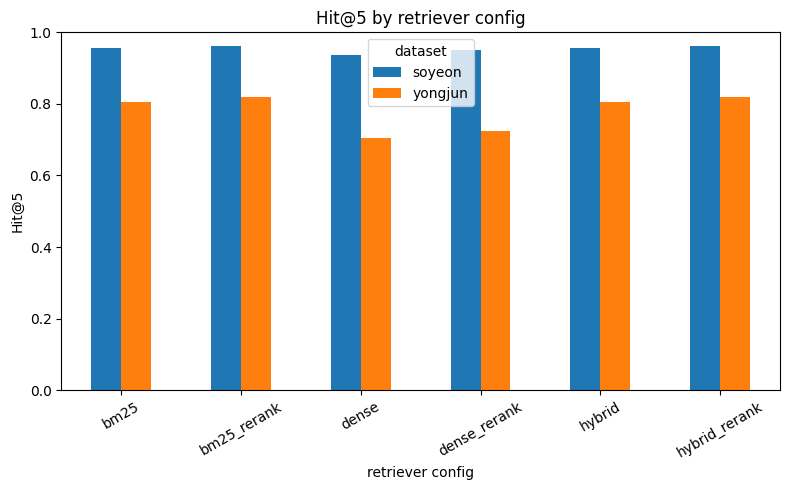

saved figure: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/retriever_metrics.png


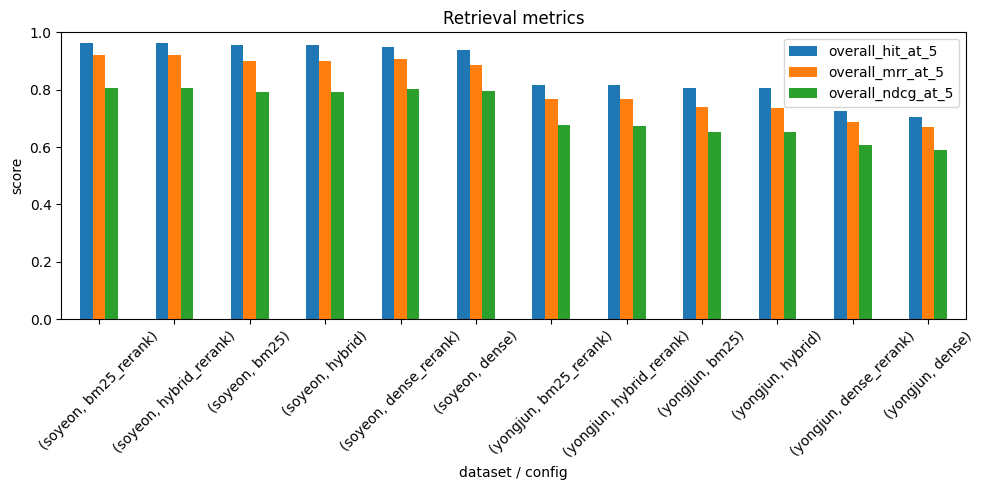

Drive output root: /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments


In [89]:
# 8. 결과 요약/시각화
# eval log에서 방금 실행한 실험을 표와 그래프로 비교합니다.

import re
import matplotlib.pyplot as plt
import pandas as pd


def extract_config_name(experiment_name: str) -> str:
    for dataset in DATASETS_TO_RUN:
        marker = f'_{dataset}'
        if marker in experiment_name:
            return experiment_name.split(marker)[0]
    return experiment_name


log_path = PROJECT_DIR / 'eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv'
if log_path.exists():
    df = pd.read_csv(log_path)
    selected = df[df['experiment_name'].isin(completed)].copy() if 'completed' in globals() and completed else df.copy()
    summary = selected.drop_duplicates('experiment_name', keep='last').copy()

    if summary.empty:
        print('표시할 평가 결과가 없습니다. 먼저 7번 실험 셀을 실행하세요.')
    else:
        dataset_pattern = r'_(' + '|'.join(re.escape(dataset) for dataset in DATASETS_TO_RUN) + r')(?=_|$)'
        summary['dataset'] = summary['experiment_name'].str.extract(dataset_pattern, expand=False)
        summary['config'] = summary['experiment_name'].map(extract_config_name)
        metric_cols = [col for col in ['overall_hit_at_5', 'overall_mrr_at_5', 'overall_ndcg_at_5'] if col in summary.columns]
        cols = [
            'dataset',
            'config',
            'experiment_name',
            'retriever_type',
            'embedding_model',
            'reranker',
            *metric_cols,
            'num_eval_questions',
            'num_scored_questions',
        ]
        cols = [col for col in cols if col in summary.columns]
        sort_cols = [col for col in ['dataset', 'overall_hit_at_5'] if col in summary.columns]
        if sort_cols:
            summary = summary.sort_values(sort_cols, ascending=[col != 'overall_hit_at_5' for col in sort_cols])
        display(summary[cols])

        if {'config', 'dataset', 'overall_hit_at_5'}.issubset(summary.columns):
            hit_pivot = summary.pivot_table(index='config', columns='dataset', values='overall_hit_at_5', aggfunc='last')
            display(hit_pivot)
            ax = hit_pivot.plot(kind='bar', figsize=(max(8, len(hit_pivot) * 1.1), 5), ylim=(0, 1), rot=30)
            ax.set_title('Hit@5 by retriever config')
            ax.set_xlabel('retriever config')
            ax.set_ylabel('Hit@5')
            ax.legend(title='dataset')
            plt.tight_layout()
            figure_path = DRIVE_OUTPUT_ROOT / 'retriever_hit_at_5.png'
            figure_path.parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(figure_path, dpi=160, bbox_inches='tight')
            print('saved figure:', figure_path)
            plt.show()

        if metric_cols:
            metric_plot = summary.set_index(['dataset', 'config'])[metric_cols]
            ax = metric_plot.plot(kind='bar', figsize=(max(10, len(metric_plot) * 0.75), 5), ylim=(0, 1), rot=45)
            ax.set_title('Retrieval metrics')
            ax.set_xlabel('dataset / config')
            ax.set_ylabel('score')
            plt.tight_layout()
            figure_path = DRIVE_OUTPUT_ROOT / 'retriever_metrics.png'
            plt.savefig(figure_path, dpi=160, bbox_inches='tight')
            print('saved figure:', figure_path)
            plt.show()
else:
    print('log file not found:', log_path)

print('Drive output root:', DRIVE_OUTPUT_ROOT)

## VM으로 결과 합치기

Colab 실행 후 Google Drive의 아래 폴더를 VM으로 가져와서 기존 결과와 비교하면 됩니다.

```text
/content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/
```

주요 파일:
- `predictions/*.jsonl`
- `eval_outputs/<experiment_name>/eval_summary.md`
- `eval_outputs/<experiment_name>/eval_results.csv`
- `eval_outputs/<experiment_name>/experiment_logs/phase1_retrieval_experiments.csv`

로컬 vector store 위치:
- FAISS: `/content/indexes/...`
- Chroma: `/content/chroma/...`

Colab 런타임이 종료되면 로컬 vector store는 사라질 수 있습니다. 재사용하고 싶으면 Drive로 zip 저장하세요.

FAISS 예:

```bash
zip -r /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/faiss_koe5_soyeon.zip /content/indexes/faiss_koe5_soyeon
```

Chroma 예:

```bash
zip -r /content/drive/MyDrive/data/rag_files/outputs/colab_hf_experiments/indexes/chroma_koe5_soyeon.zip /content/chroma/chroma_koe5_soyeon
```